In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
import os
import sys

import geopandas as gp
import rioxarray
from shapely.geometry import mapping


import warnings
warnings.filterwarnings("ignore")
!conda list netcdf4

# packages in environment at /home/aelyoussoufi/miniconda3/envs/latest:
#
# Name                    Version                   Build  Channel
netcdf4                   1.7.2           nompi_py310h5146f0f_101    conda-forge


In [2]:
def detrend_dim(da, dim, deg=1):
    # detrend along a single dimension
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

In [3]:
def init_climregions():
    se_dict={'name':'Southeast','short_name':'SE',
             'states':['AL','FL','GA','NC','SC','VA']}
    ne_dict={'name':'Northeast','short_name':'NE',
             'states':['CT','DE','ME','MD','MA','NH','NJ','NY','PA','RI','VT']}
    umidwest_dict={'name':'Upper Midwest','short_name':'UMW',
             'states':['IA','MI','MN','WI']}
    ohiov_dict={'name':'Ohio Valley','short_name':'OHV',
                'states':['IL','IN','KY','MI','MO','OH','TN','WV']}
    nrockies_dict={'name':'Northern Rockies and Plains','short_name':'NRP',
                   'states':['MT','NE','ND','SD','WY']}
    south_dict={'name':'South','short_name':'SOUTH',
                   'states':['AR','KS','LA','MS','OK','TX']}
    sw_dict={'name':'Southwest','short_name':'SW',
                   'states':['AZ','CO','NM','UT']}
    nw_dict={'name':'Northwest','short_name':'NW',
                   'states':['ID','OR','WA']}
    west_dict={'name':'West','short_name':'WEST',
                'states':['CA','NV']}
    


    regs_dict=[se_dict,ne_dict,umidwest_dict,ohiov_dict,nrockies_dict,south_dict,sw_dict,nw_dict,west_dict]
    
    return regs_dict



def daily_climo(da, varname, **kwargs):
    # This function calculates climatology following the SubX smoothed and periodic climatology method.
    clim_fname = kwargs.get('fname', None)
    
    # Average daily data
    da_day_clim = da.groupby('time.dayofyear').mean('time')  # Use 'time' for grouping
    
    # Rechunk for time
    da_day_clim = da_day_clim.chunk({'dayofyear': 366})
    
    # Pad the daily climatology with NaNs
    x = np.empty((366, len(da_day_clim.y), len(da_day_clim.x)))  # Use 'y' and 'x' for latitude and longitude
    x.fill(np.nan)
    _da = xr.DataArray(
        x,
        name=varname,
        coords=[np.linspace(1, 366, num=366, dtype=np.int64), da_day_clim.y, da_day_clim.x],  # Use 'y' and 'x'
        dims=da_day_clim.dims
    )
    da_day_clim_wnan = da_day_clim.combine_first(_da)
    
    # Period rolling twice to make it triangular smoothing
    da_day_clim_smooth = da_day_clim_wnan.copy()
    for i in range(2):
        # Extend the DataArray to allow rolling to be periodic
        da_day_clim_smooth = xr.concat(
            [da_day_clim_smooth[-15:], da_day_clim_smooth, da_day_clim_smooth[:15]], 'dayofyear'
        )
        # Rolling mean
        da_day_clim_smooth = da_day_clim_smooth.rolling(dayofyear=31, center=True, min_periods=1).mean()
        # Drop the periodic boundaries
        da_day_clim_smooth = da_day_clim_smooth.isel(dayofyear=slice(15, -15))
    
    # Extract the original days
    da_day_clim_smooth = da_day_clim_smooth.sel(dayofyear=da_day_clim.dayofyear)
    da_day_clim_smooth.name = varname
    ds_day_clim_smooth = da_day_clim_smooth.to_dataset()
    
    # Save to file if filename is provided, otherwise return the data
    if clim_fname:
        ds_day_clim_smooth.to_netcdf(clim_fname)
        return True
    else:
        return ds_day_clim_smooth

In [4]:
baseDir='/data/esplab/aelyoussoufi/'
dataset='snow_water_equivalent'
varname='snow_water_equivalent'
files=baseDir+'snow_water_equivalent.nc'  # File in current directory
states_shapefile='cb_2018_us_state_20m.shp'  # Shapefile in current directory
outPath = '.' 
regs_dict=init_climregions()

In [5]:
files

'/data/esplab/aelyoussoufi/snow_water_equivalent.nc'

In [6]:
ds=xr.open_mfdataset(files)
ds

<xarray.Dataset> Size: 5GB
Dimensions:                (time: 52, Y: 3351, X: 6935)
Coordinates:
  * time                   (time) object 416B 2003-12-01 00:00:00 ... 2020-12...
  * Y                      (Y) float64 27kB 24.95 24.96 24.97 ... 52.86 52.87
  * X                      (X) float64 55kB -124.7 -124.7 ... -66.95 -66.95
Data variables:
    snow_water_equivalent  (time, Y, X) float32 5GB dask.array<chunksize=(1, 3351, 6935), meta=np.ndarray>

In [7]:
ds = ds.assign_coords(longitude=(((ds.X + 180) % 360) - 180)).sortby('X')
# Rename dimensions from 'X' and 'Y' to 'x' and 'y'
ds = ds.rename({'X': 'x', 'Y': 'y'})

# Assign a CRS to the dataset (e.g., WGS84)
ds = ds.rio.write_crs("EPSG:4326")
print("Dataset CRS:", ds.rio.crs)

# Load the shapefile
states = gp.read_file(states_shapefile)

# Assign a CRS to the shapefile (e.g., WGS84)
states = states.set_crs("EPSG:4326")
print("Shapefile CRS:", states.crs)

# Reproject the dataset to match the shapefile's CRS (if necessary)
if states.crs != ds.rio.crs:
    print("Reprojecting dataset to match shapefile CRS...")
    ds = ds.rio.reproject(states.crs)


Dataset CRS: EPSG:4326
Shapefile CRS: EPSG:4326


In [8]:

states = states.set_crs("EPSG:4326")
print("Shapefile CRS:", states.crs)
if states.crs != ds.rio.crs:
    print("Reprojecting dataset to match shapefile CRS...")
    ds = ds.rio.reproject(states.crs)

Shapefile CRS: EPSG:4326


In [9]:
# Calculate the climatology
climatology = daily_climo(ds[varname], varname)

# Calculate the anomalies
anomalies = ds[varname].groupby('time.dayofyear') - climatology[varname]

# Create a mask for all states at once
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50
mask = us_states.mask(ds.x, ds.y)  # Use 'x' and 'y' for longitude and latitude


In [10]:
# Mask the anomalies data
anomalies_us = anomalies.where(mask >= 0)

# Assign a CRS to the anomalies dataset
anomalies_us = anomalies_us.rio.write_crs("EPSG:4326")

# Reproject the anomalies dataset to match the shapefile's CRS (if necessary)
if states.crs != anomalies_us.rio.crs:
    print("Reprojecting anomalies to match shapefile CRS...")
    anomalies_us = anomalies_us.rio.reproject(states.crs)


In [11]:
# Initialize a list to store state-level anomalies
state_anomalies = []

# Loop through each state and compute the mean anomaly
for state in states.itertuples():
    print(f"Processing state: {state.STUSPS}")
    
    try:
        # Clip the anomalies data to the state's geometry
        state_geometry = state.geometry
        anomalies_clipped = anomalies_us.rio.clip([state_geometry], states.crs, drop=True)
        
        # Check if the clipped data is empty
        if anomalies_clipped.isnull().all():
            print(f"No data found for state: {state.STUSPS}. Skipping...")
            continue
        
        # Compute the mean anomaly for the state
        state_mean_anomaly = anomalies_clipped.mean(dim=['y', 'x']).values
        
        # Append the result to the list
        state_anomalies.append({'State': state.STUSPS, 'Anomaly': state_mean_anomaly})
    
    except Exception as e:
        print(f"Error processing state {state.STUSPS}: {e}. Skipping...")
        continue

# Convert the list to a DataFrame
state_anomalies_df = pd.DataFrame(state_anomalies)

# Drop rows with NaN anomalies (e.g., for regions outside the US)
state_anomalies_df = state_anomalies_df.dropna(subset=['Anomaly'])

# Print the resulting DataFrame
print(state_anomalies_df)


Processing state: MD
Processing state: IA
Processing state: DE
Processing state: OH
Processing state: PA
Processing state: NE
Processing state: WA
Processing state: PR
Error processing state PR: No data found in bounds. Data variable: snow_water_equivalent. Skipping...
Processing state: AL
Processing state: AR
Processing state: NM
Processing state: TX
Processing state: CA
Processing state: KY
Processing state: GA
Processing state: WI
Processing state: OR
Processing state: MO
Processing state: VA
Processing state: TN
Processing state: LA
Processing state: NY
Processing state: MI
Processing state: ID
Processing state: FL
Processing state: AK
Error processing state AK: No data found in bounds. Data variable: snow_water_equivalent. Skipping...
Processing state: IL
Processing state: MT
Processing state: MN
Processing state: IN
Processing state: MA
Processing state: KS
Processing state: NV
Processing state: VT
Processing state: CT
Processing state: NJ
Processing state: DC
Processing state: N

In [13]:
print(state_anomalies_df['Anomaly'].head())

0    [1.229823012155956, 0.04929540948472703, 9.465...
1    [-2.160008694915873, -12.454294917931811, 17.9...
2    [-1.004573952930701, 0.9264519854307668, -3.50...
3    [-2.5570673483850466, -0.9042081468859738, -1....
4    [-0.865949719444727, -0.5738185321947215, 30.5...
Name: Anomaly, dtype: object


In [14]:
# Convert the 'Anomaly' column to scalar values
state_anomalies_df['Anomaly'] = state_anomalies_df['Anomaly'].apply(lambda x: float(x[0]))  # Extract the first value

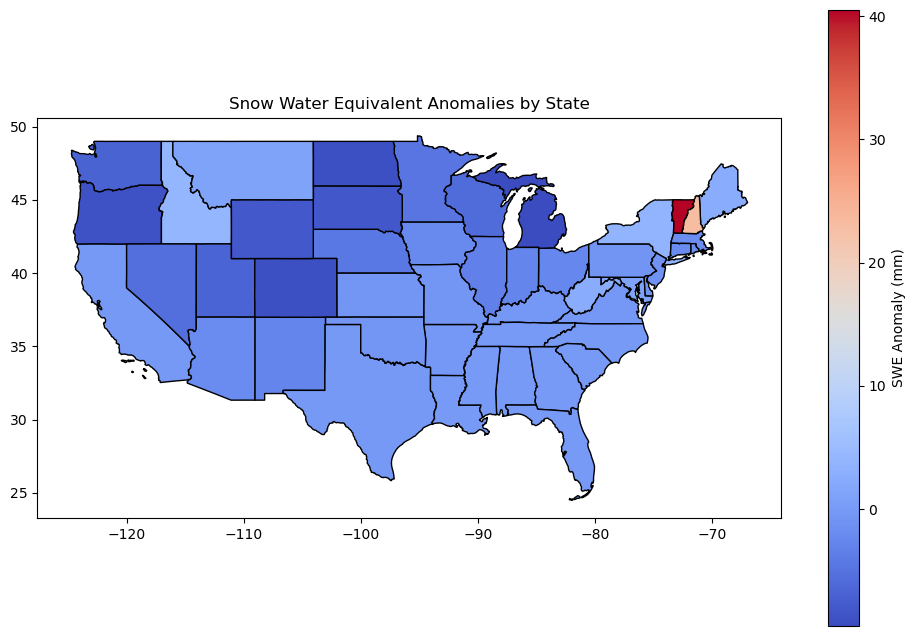

In [17]:
# Merge the anomaly data with the states GeoDataFrame
states_with_anomalies = states.merge(state_anomalies_df, left_on='STUSPS', right_on='State')

# Plot the choropleth map
fig, ax = plt.subplots(figsize=(12, 8))
states_with_anomalies.plot(column='Anomaly', ax=ax, legend=True,
                           cmap='coolwarm', edgecolor='black',
                           legend_kwds={'label': "SWE Anomaly (mm)"})
plt.title('Snow Water Equivalent Anomalies by State')
plt.show()

In [ ]:
ds_us=ds.sel(Y=slice(25,50),X=slice(-125,-50)).compute()
ds_us=ds_us.rename({'Y':'lat','X':'lon'})

In [ ]:
#for state_num,abbrv in zip(states.index.values,states['STUSPS'].values):

    #print(abbrv)
    
   # ds_state=ds_us.where(ds_us['mask']==state_num,drop=True).compute()
    
    #if (len(ds_state['lat'])>0 and len(ds_state['lon']>0)):
    
        #ds_climo=daily_climo(ds_state['snow_water_equivalent'],'snow_water_equivalent')['snow_water_equivalent'].chunk({'dayofyear':366,'lat':'auto','lon':'auto'})
       # ds_anoms=ds_state['snow_water_equivalent'].groupby('time.dayofyear')-ds_climo
       # outfile='../swe.2003-01-01.2020-12-31.'+abbrv+'.nc'
       # ds_anoms.to_netcdf(outfile)

In [ ]:
#for state_num,abbrv in zip(states.index.values,states['STUSPS'].values):

    print(abbrv)
    
    ds_state=ds_us.where(ds_us['mask']==state_num,drop=True).compute()
    
    if (len(ds_state['lat'])>0 and len(ds_state['lon']>0)):
    
        ds_climo=daily_climo(ds_state['snow_water_equivalent'],'snow_water_equivalent')['snow_water_equivalent'].chunk({'dayofyear':366,'lat':'auto','lon':'auto'})
        ds_anoms=ds_state['snow_water_equivalent'].groupby('time.dayofyear')-ds_climo
        outfile='../swe.2003-01-01.2020-12-31.'+abbrv+'.nc'
        ds_anoms.to_netcdf(outfile)